In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import Uniform

# --- 0. Configuration & Device ---
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
np.random.seed(42)

Using device: cuda


In [2]:
# --- 1. The Neural Network (Outputs Stresses Directly) ---
class PINN(nn.Module):
    def __init__(self, layers, r_domain, z_domain):
        super(PINN, self).__init__()
        self.activation = nn.SiLU()
        
        # Normalization bounds (important for convergence)
        self.lb = torch.tensor([0.0, 0.0]).float().to(device)
        self.ub = torch.tensor([r_domain, z_domain]).float().to(device)
        
        self.layers = nn.ModuleList()
        # Input: 2 (r, z) -> Hidden Layers
        self.layers.append(nn.Linear(2, layers[0]))
        for i in range(len(layers) - 1):
            self.layers.append(nn.Linear(layers[i], layers[i+1]))
        
        # Output: 2 displacements [u_r,w]
        self.layers.append(nn.Linear(layers[-1], 2))
        
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_normal_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        # Normalize inputs to [-1, 1] range
        x_norm = 2.0 * (x - self.lb) / (self.ub - self.lb) - 1.0
        
        out = x_norm
        for i in range(len(self.layers) - 1):
            out = self.activation(self.layers[i](out))
        out = self.layers[-1](out)
        return out # returns [u_r, w]

In [3]:
def calc_deriv(f, x):
    df_dx = torch.autograd.grad(f, x, torch.ones_like(f), create_graph=True, retain_graph=True)[0]
    return df_dx

# --- 2. The Physics Class (Equilibrium + Compatibility) ---
class BoussinesqPINN:
    def __init__(self, network, nu, P_load, domain_r, domain_z, total_epochs, sigma_load, decay_rate):
        self.network = network.to(device)
        self.nu = nu
        self.P_load = P_load # Magnitude of point load
        self.R_DOMAIN = domain_r
        self.Z_DOMAIN = domain_z
        self.sigma_load = sigma_load
        self.decay_rate = decay_rate
        
        # Optimizer
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=1e-3)
        
        #  CosineAnnealingLR scheduler
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            self.optimizer, T_max=total_epochs, eta_min=1e-7
        )
        
        # Loss History
        self.history = []
        self.Total_loss, self.Loss_eq, self.Loss_far, self.Loss_bc_sigma, self.Loss_bc_tau = [], [], [], [], []

    def get_stresses(self, r, z):
        """Forward pass to get stresses."""
        r.requires_grad = True
        z.requires_grad = True

        # 1. Get displacements from the network
        coord = torch.cat([r, z], dim=1)
        u = self.network(coord)  # u: [u_r, w]
        u_r = u[:, [0]]
        w   = u[:, [1]]

        # 2. Compute strains
        eps_rr = calc_deriv(u_r, r)
        eps_zz = calc_deriv(w, z)
        eps_tt = u_r / r  # Avoid division by zero at r=0
        eps_rz = calc_deriv(u_r, z) + calc_deriv(w, r)

        # 3. Compute stresses (Hooke's Law for isotropic materials)
        E = 1.0  # Assume unit Young's modulus for simplicity
        nu = self.nu
        coeff = E / ((1 + nu) * (1 - 2 * nu))

        s_rr = coeff * ((1 - nu) * eps_rr + nu * (eps_tt + eps_zz))
        s_zz = coeff * ((1 - nu) * eps_zz + nu * (eps_rr + eps_tt))
        s_tt = coeff * ((1 - nu) * eps_tt + nu * (eps_rr + eps_zz))
        t_rz = E / (2 * (1 + nu)) * eps_rz
        return s_zz, s_rr, s_tt, t_rz
    

    def compute_residuals(self, r, z):
        """Computes Equilibrium and Compatibility (Beltrami-Michell) residuals."""
        r.requires_grad = True
        z.requires_grad = True
        
        s_zz, s_rr, s_tt, t_rz = self.get_stresses(r, z)
        
        # --- First Derivatives ---
        dsrr_dr = calc_deriv(s_rr, r)
        dsrr_dz = calc_deriv(s_rr, z)
        
        dszz_dr = calc_deriv(s_zz, r)
        dszz_dz = calc_deriv(s_zz, z)
        
        dstt_dr = calc_deriv(s_tt, r)
        dstt_dz = calc_deriv(s_tt, z)

        dtrz_dr = calc_deriv(t_rz, r)
        dtrz_dz = calc_deriv(t_rz, z)

        # --- A. Equilibrium Equations (Axisymmetric) ---
        # 1. Radial Equilibrium
        eq1 = dsrr_dr + dtrz_dz + (s_rr - s_tt) / r
        # 2. Vertical Equilibrium
        eq2 = dtrz_dr + dszz_dz + t_rz / r

        return eq1, eq2

    def sample_points(self, n_pde, n_bc):
        """
        Resample all collocation points for each training step.
        """
        # 1. PDE Points (with bias near load)
        N_LOG     = int(n_pde * 0.7)
        N_UNIFORM = n_pde - N_LOG

        N_SURFACE      = int(n_bc * 0.4)
        N_FARFIELD     = int(n_bc * 0.6)

        # 1. Define log bounds
        log_min = np.log(0.1)
        log_max = np.log(self.R_DOMAIN)

        # 2. Sample uniformly in log space
        r_log = torch.rand(N_LOG, 1) * (log_max - log_min) + log_min
        r_pde_reg = torch.exp(r_log).to(device) # r values heavily biased towards 0.1

        # z can remain Uniform or also be clustered near 0 if needed
        z_pde_reg = Uniform(0.0, self.Z_DOMAIN).sample((N_LOG, 1)).to(device)

        #Standard uniform sampling for the rest
        r_pde_unif = Uniform(0.1, self.R_DOMAIN).sample((N_UNIFORM, 1)).to(device)
        z_pde_unif = Uniform(0.0, self.Z_DOMAIN).sample((N_UNIFORM, 1)).to(device)  

        r_pde_reg = torch.row_stack([r_pde_reg, r_pde_unif])
        z_pde_reg = torch.row_stack([z_pde_reg, z_pde_unif])

        pde_pts   = torch.column_stack([r_pde_reg, z_pde_reg])

        # 2. BC Points
        # Surface
        r_surface   = Uniform(0.1, self.R_DOMAIN).sample((N_SURFACE, 1))
        surface_pts = torch.column_stack([r_surface, torch.zeros_like(r_surface)]).to(device)

        # Far-field
        r_far_vert    = torch.full((N_FARFIELD, 1), self.R_DOMAIN)
        z_far_vert    = Uniform(0.0, self.Z_DOMAIN).sample((N_FARFIELD, 1))

        r_far_horiz   = Uniform(0.1, self.R_DOMAIN).sample((N_FARFIELD, 1))
        z_far_horiz   = torch.full((N_FARFIELD, 1), self.Z_DOMAIN)

        far_field_pts = torch.row_stack([
            torch.column_stack([r_far_vert,  z_far_vert ]),
            torch.column_stack([r_far_horiz, z_far_horiz])
        ]).to(device)
        
        return pde_pts, surface_pts, far_field_pts

    def loss_function(self, pde_pts, surf_pts, far_pts):
        # A. PDE Residuals
        r_pde, z_pde = pde_pts[:, [0]], pde_pts[:, [1]]
        eq1, eq2= self.compute_residuals(r_pde, z_pde)
        
        loss_eq = torch.mean(eq1**2) + torch.mean(eq2**2)

        # B. Surface Boundary (Load)
        r_s, z_s = surf_pts[:, [0]], surf_pts[:, [1]]
        s_zz_s, _, _, t_rz_s = self.get_stresses(r_s, z_s)
        
        #Load Approximation (Gaussian to approximate point load P)
        load_profile = -1.0 *  (self.P_load / (2 * np.pi * self.sigma_load**2)) * torch.exp(-r_s**2 / (2 * self.sigma_load**2))

        loss_bc_sigma = torch.mean((s_zz_s - load_profile)**2)
        loss_bc_tau = torch.mean(t_rz_s**2) # Shear is 0
        
        # C. Far Field (Zero Stress)
        r_f, z_f = far_pts[:, [0]], far_pts[:, [1]]
        s_zz_f, s_rr_f, s_tt_f, t_rz_f = self.get_stresses(r_f, z_f)
        loss_far = torch.mean(s_zz_f**2 + s_rr_f**2 + s_tt_f**2 + t_rz_f**2)

        total_loss = loss_eq + 10*(loss_bc_sigma + loss_bc_tau + loss_far)

        return total_loss, loss_eq, loss_far, loss_bc_sigma, loss_bc_tau

    def train(self, epochs, n_pde, n_bc):
        
        print("--- Starting Training (Gaussian regularized load, Resampling) ---")

        print(f'{"Epoch":^10} | {"Total Loss":^10} | {"Loss EQ":^10} | {"Loss Far":^10} | {"Loss BC Sigma":^10} | {"Loss BC Tau":^10} | {"LR":^10} | {"Sigma Load":^10}')
        print(75*"-")

        pde_pts, surf_pts, far_pts = self.sample_points(n_pde, n_bc)
        
        for epoch in range(epochs):
            self.network.train()
            self.optimizer.zero_grad()
            
            # Resample rarely to keep training stable
            if epoch % 1000 == 0 and epoch > 0:
                pde_pts, surf_pts, far_pts = self.sample_points(n_pde, n_bc)
            
            if epoch % 2000 == 0 and epoch > 1 and self.sigma_load > 0.2:
                self.sigma_load *= self.decay_rate
                       
            loss, loss_eq, loss_far, loss_bc_sigma, loss_bc_tau = self.loss_function(pde_pts, surf_pts, far_pts)

            loss.backward()
            self.optimizer.step()
            self.scheduler.step()
            
            self.Total_loss.append(loss.item())
            self.Loss_eq.append(loss_eq.item())
            self.Loss_far.append(loss_far.item())
            self.Loss_bc_sigma.append(loss_bc_sigma.item())
            self.Loss_bc_tau.append(loss_bc_tau.item())
           
            if epoch % 500 == 0:
                print(f"{epoch+1:5d}/{epochs} | "
                      f"{loss.item():10.4e} | "
                      f"{loss_eq.item():10.4e} | "
                      f"{loss_far.item():10.4e} | "
                      f"{loss_bc_sigma.item():10.4e} | "
                      f"{loss_bc_tau.item():10.4e} | "
                      f"{self.optimizer.param_groups[0]['lr']:10.4e} | "
                      f"{self.sigma_load:10.4e} ")
                
                if loss.item() < 1e-8:
                    print("Early stopping criterion met.")
                    break


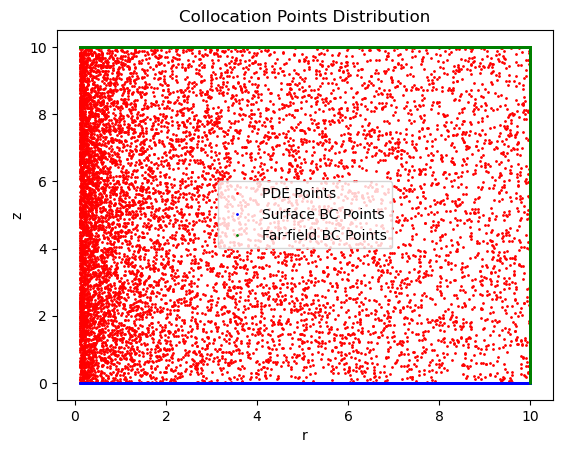

In [4]:
# --- 3. Execution & Visualization ---

# Parameters
R_DOMAIN = 10.0
Z_DOMAIN = 10.0
NU = 0.3
P_LOAD = 100.0 # Load magnitude

EPOCHS = 8_000
N_PDE  = 10_000
N_BC   = 5_000

SIGMA_LOAD = 3.2
DECAY_RATE = 0.25

# Model
net = PINN(layers=[2, 100, 100, 100, 100, 100, 100, 2], r_domain=R_DOMAIN, z_domain=Z_DOMAIN)
solver = BoussinesqPINN(net, NU, P_LOAD, R_DOMAIN, Z_DOMAIN, EPOCHS, SIGMA_LOAD, DECAY_RATE)

pde_pts, surf_pts, far_pts = solver.sample_points(N_PDE, N_BC)

plt.figure()
plt.plot(      pde_pts[:,0].cpu().numpy(),       pde_pts[:,1].cpu().numpy(), 'ro', markersize=1, label='PDE Points')
plt.plot(  surf_pts[:,0].cpu().numpy(),   surf_pts[:,1].cpu().numpy(), 'bo', markersize=1, label='Surface BC Points')
plt.plot(far_pts[:,0].cpu().numpy(), far_pts[:,1].cpu().numpy(), 'go', markersize=1, label='Far-field BC Points')
plt.xlabel('r')
plt.ylabel('z')
plt.title('Collocation Points Distribution')
plt.legend()
plt.show()

In [5]:
filename = 'boussinesq_model_CP5.pth'

cargar_modelo_entrenado = False

if cargar_modelo_entrenado:
    boussinesq_solver = torch.load(filename, weights_only=False)
    print("Model loaded from ", filename)

else:
    # Training call
    solver.train(epochs=EPOCHS, n_pde=N_PDE, n_bc=N_BC)
    torch.save(solver, filename)
    print("\n--- Training Complete --- Model saved to", filename)


--- Starting Training (Gaussian regularized load, Resampling) ---
  Epoch    | Total Loss |  Loss EQ   |  Loss Far  | Loss BC Sigma | Loss BC Tau |     LR     | Sigma Load
---------------------------------------------------------------------------
    1/8000 | 6.6738e+00 | 1.8301e-04 | 5.2555e-06 | 6.6736e-01 | 3.9759e-07 | 1.0000e-03 | 3.2000e+00 
  501/8000 | 3.5677e-02 | 2.5885e-02 | 5.0359e-04 | 1.0477e-04 | 3.7081e-04 | 9.9036e-04 | 3.2000e+00 
 1001/8000 | 3.0920e-02 | 2.4033e-02 | 3.0253e-04 | 7.4050e-05 | 3.1205e-04 | 9.6187e-04 | 3.2000e+00 
 1501/8000 | 2.7789e-02 | 2.2728e-02 | 2.3152e-04 | 6.3586e-05 | 2.1100e-04 | 9.1563e-04 | 3.2000e+00 
 2001/8000 | 3.2815e+02 | 2.2478e-02 | 1.6423e-04 | 3.2812e+01 | 1.4606e-04 | 8.5343e-04 | 8.0000e-01 
 2501/8000 | 9.3744e+00 | 6.3136e+00 | 9.2900e-03 | 5.3001e-02 | 2.4379e-01 | 7.7764e-04 | 8.0000e-01 
 3001/8000 | 6.6965e+00 | 5.4210e+00 | 5.3022e-03 | 1.9853e-02 | 1.0239e-01 | 6.9119e-04 | 8.0000e-01 
 3501/8000 | 3.7085e+00 | 2.899


--- Plotting Learning Curve ---


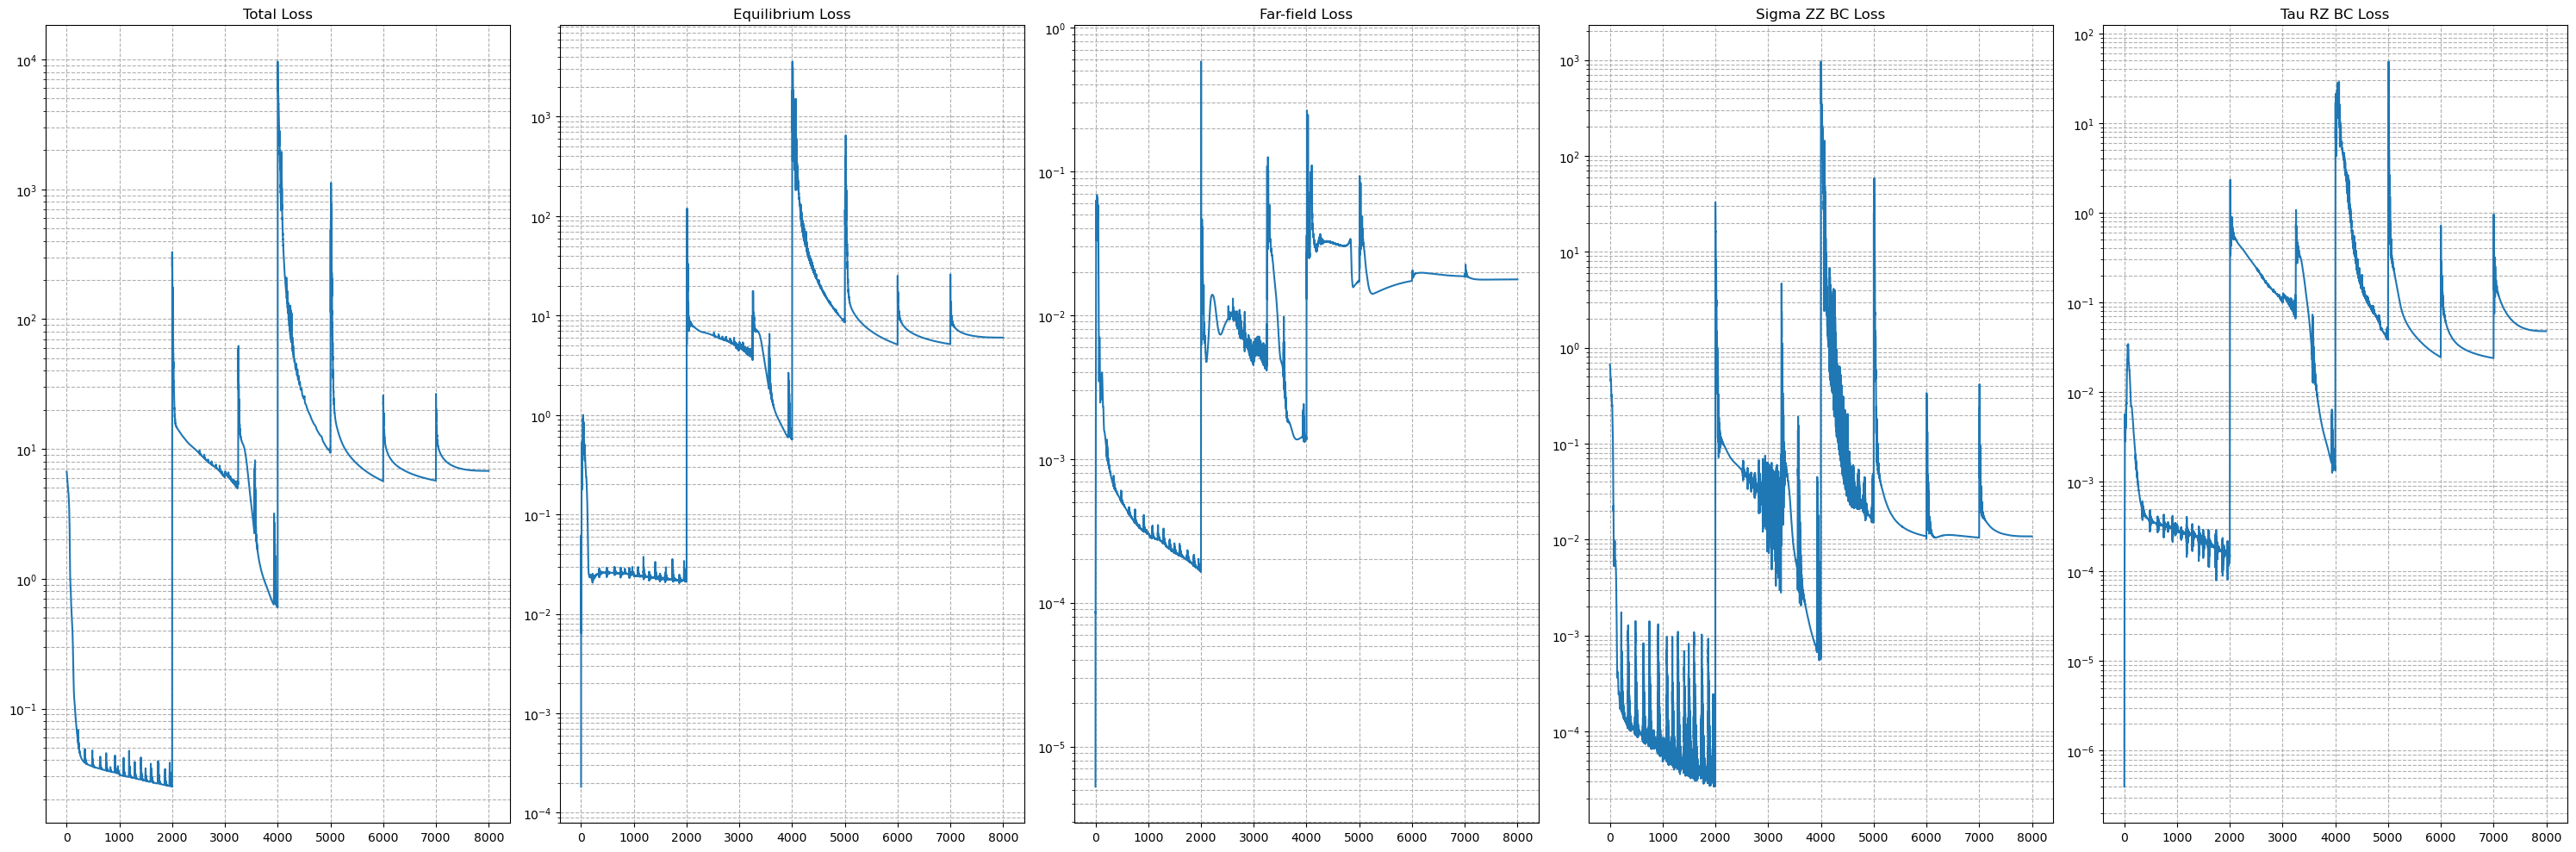

In [6]:
# Plotting lerarning curves

print("\n--- Plotting Learning Curve ---")

fig, axes = plt.subplots(1, 5, figsize=(30, 10))

# Total Loss
axes[0].plot(solver.Total_loss)
axes[0].set_title('Total Loss')
axes[0].set_yscale('log')
axes[0].grid(True, which="both", ls="--")

# EQ Loss
axes[1].plot(solver.Loss_eq)
axes[1].set_title('Equilibrium Loss')
axes[1].set_yscale('log')
axes[1].grid(True, which="both", ls="--")

# Far-field Loss
axes[2].plot(solver.Loss_far)
axes[2].set_title('Far-field Loss')
axes[2].set_yscale('log')
axes[2].grid(True, which="both", ls="--")

# BC Loss SIGMA
axes[3].plot(solver.Loss_bc_sigma)
axes[3].set_title('Sigma ZZ BC Loss')
axes[3].set_yscale('log')
axes[3].grid(True, which="both", ls="--")

# BC Loss TAU
axes[4].plot(solver.Loss_bc_tau)
axes[4].set_title('Tau RZ BC Loss')
axes[4].set_yscale('log')
axes[4].grid(True, which="both", ls="--")

plt.tight_layout()
plt.show()

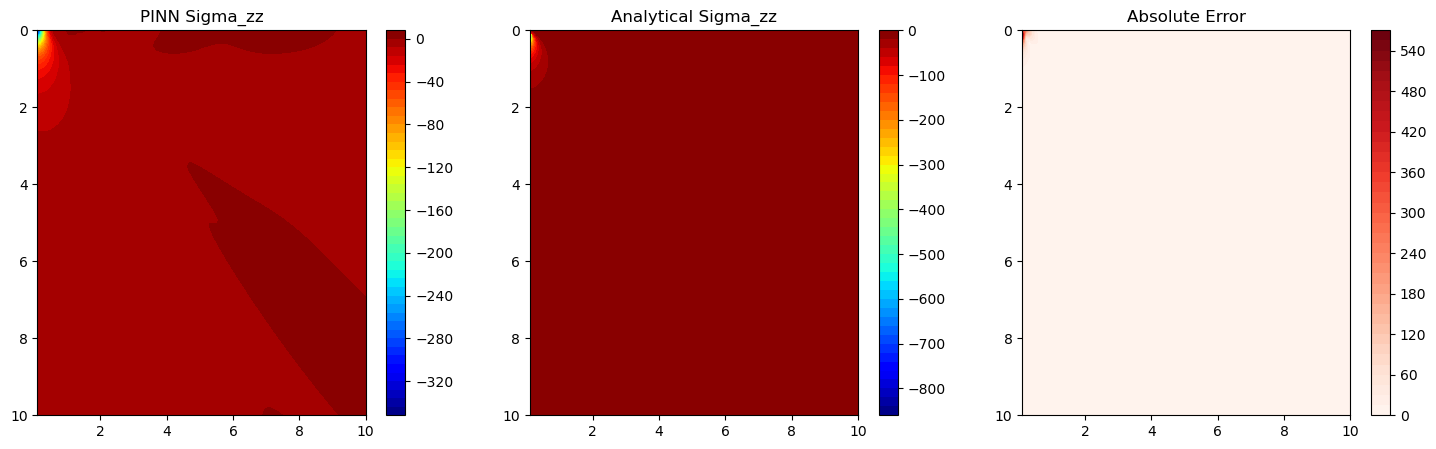

In [7]:
# --- Plotting ---
def plot_results():
    # Grid for plotting
    r = np.linspace(0.1, R_DOMAIN, 100)
    z = np.linspace(0.0, Z_DOMAIN, 100)
    R, Z = np.meshgrid(r, z)
    
    # Analytical Boussinesq (Sigma ZZ)
    # sigma_zz = - (3P / 2*pi) * (z^3 / rho^5)
    rho = np.sqrt(R**2 + Z**2)
    s_zz_analytical = - (3 * P_LOAD / (2 * np.pi)) * (Z**3 / rho**5)
    
    # PINN Prediction
    r_tens = torch.tensor(R.flatten(), dtype=torch.float32).unsqueeze(1).to(device)
    z_tens = torch.tensor(Z.flatten(), dtype=torch.float32).unsqueeze(1).to(device)
    
    s_zz_pred, _, _, _ = solver.get_stresses(r_tens, z_tens)
    s_zz_pred = s_zz_pred.cpu().detach().numpy().reshape(100, 100)
  
    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # PINN
    c1 = axes[0].contourf(R, Z, s_zz_pred, levels=50, cmap='jet')
    plt.colorbar(c1, ax=axes[0])
    axes[0].set_title("PINN Sigma_zz")
    axes[0].invert_yaxis()
    
    # Analytical
    c2 = axes[1].contourf(R, Z, s_zz_analytical, levels=50, cmap='jet')
    plt.colorbar(c2, ax=axes[1])
    axes[1].set_title("Analytical Sigma_zz")
    axes[1].invert_yaxis()
    
    # Error
    err = np.abs(s_zz_pred - s_zz_analytical)
    c3 = axes[2].contourf(R, Z, err, levels=50, cmap='Reds')
    plt.colorbar(c3, ax=axes[2])
    axes[2].set_title("Absolute Error")
    axes[2].invert_yaxis()
    
    plt.show()
    

plot_results()